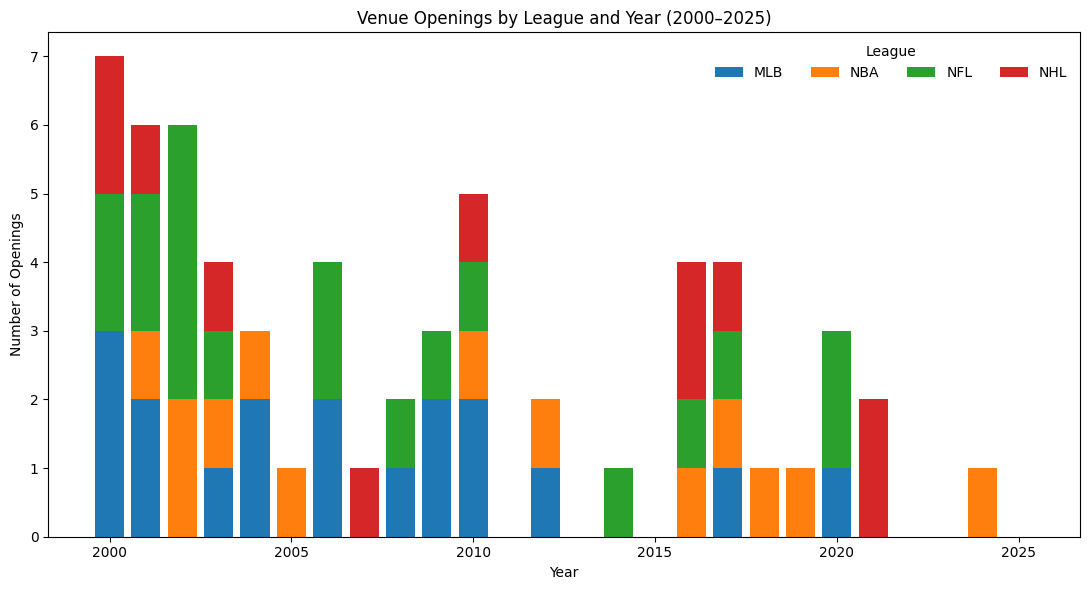

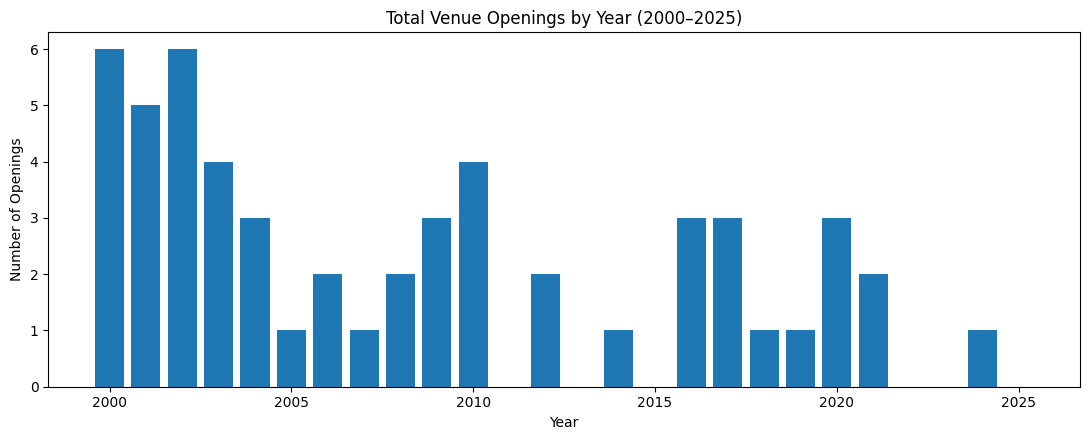

In [1]:
# Paths
EVENTS_CSV = r"/Users/mickeynguyen/Documents/School /Stadium Paper/Output/events_2000_2025_allleagues.csv"

import pandas as pd
import matplotlib.pyplot as plt

# Load
ev = pd.read_csv(EVENTS_CSV)
ev["facility_type"] = ev["facility_type"].astype(str).str.lower()
ev["open_year"] = pd.to_numeric(ev["open_year"], errors="coerce")

# League dictionaries
NFL = {
    "49ers","bears","bengals","bills","broncos","browns","buccaneers","cardinals","chargers","chiefs","colts",
    "commanders","cowboys","dolphins","eagles","falcons","giants","jaguars","jets","lions","packers","panthers",
    "patriots","raiders","rams","ravens","saints","seahawks","steelers","texans","titans","vikings"
}
MLB = {
    "angels","astros","athletics","blue jays","braves","brewers","cardinals","cubs","diamondbacks","dodgers",
    "giants","guardians","mariners","marlins","mets","nationals","orioles","padres","phillies","pirates",
    "rangers","rays","red sox","reds","rockies","royals","tigers","twins","white sox","yankees"
}
NBA = {
    "hawks","celtics","nets","hornets","bulls","cavaliers","mavericks","nuggets","pistons","warriors","rockets",
    "pacers","clippers","lakers","grizzlies","heat","bucks","timberwolves","pelicans","knicks","thunder","magic",
    "76ers","sixers","seventy sixers","suns","trail blazers","blazers","kings","spurs","raptors","jazz","wizards"
}
NHL = {
    "ducks","coyotes","bruins","sabres","flames","hurricanes","blackhawks","avalanche","blue jackets","stars",
    "red wings","oilers","panthers","kings","wild","canadiens","predators","devils","islanders","rangers","senators",
    "flyers","penguins","sharks","kraken","blues","lightning","maple leafs","canucks","golden knights","capitals","jets"
}

def infer_leagues(teams: str, facility_type: str):
    s = str(teams).lower()
    leagues = set()
    ft = (facility_type or "").lower()
    if ft == "stadium":
        if any(tok.lower() in s for tok in NFL): leagues.add("NFL")
        if any(tok.lower() in s for tok in MLB): leagues.add("MLB")
    elif ft == "arena":
        if any(tok.lower() in s for tok in NBA): leagues.add("NBA")
        if any(tok.lower() in s for tok in NHL): leagues.add("NHL")
    else:
        if any(tok.lower() in s for tok in NFL): leagues.add("NFL")
        if any(tok.lower() in s for tok in MLB): leagues.add("MLB")
        if any(tok.lower() in s for tok in NBA): leagues.add("NBA")
        if any(tok.lower() in s for tok in NHL): leagues.add("NHL")
    return list(leagues) if leagues else []

# One row per (event, league)
ev["leagues_list"] = ev.apply(lambda r: infer_leagues(r.get("teams",""), r.get("facility_type","")), axis=1)
ev_league = ev.explode("leagues_list").rename(columns={"leagues_list":"league"})

# *** Key fix: drop NaN/Unknown leagues so they can't appear in the legend ***
ev_league = ev_league.dropna(subset=["league"])
ev_league = ev_league[ev_league["league"] != "Unknown"]

# Counts
by_year_league = (
    ev_league.groupby(["open_year","league"], as_index=False)
             .size()
             .rename(columns={"size":"openings"})
)

total_by_year = (
    ev.groupby("open_year", as_index=False)
      .size()
      .rename(columns={"size":"total_openings"})
      .sort_values("open_year")
)

# --- Plot 1: Stacked bars by league/year (inline) ---
pivot = by_year_league.pivot(index="open_year", columns="league", values="openings").fillna(0)
# reindex to show every year 2000–2025; fill missing with 0
pivot = pivot.reindex(index=range(2000, 2026), fill_value=0)
# (belt-and-suspenders) ensure there is no NaN column
pivot = pivot.loc[:, pivot.columns.notna()]

plt.figure(figsize=(11, 6))
bottom = None
for col in pivot.columns:
    vals = pivot[col].values
    if bottom is None:
        plt.bar(pivot.index, vals, label=col)
        bottom = vals
    else:
        plt.bar(pivot.index, vals, bottom=bottom, label=col)
        bottom = bottom + vals
plt.title("Venue Openings by League and Year (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Openings")
plt.legend(title="League", ncol=4, frameon=False)
plt.tight_layout()
plt.show()

# --- Plot 2: Total openings by year (inline) ---
# (Reindex to full year range for visual consistency)
tot = total_by_year.set_index("open_year").reindex(range(2000, 2026)).fillna(0).reset_index()
tot.rename(columns={"index":"open_year"}, inplace=True)

plt.figure(figsize=(11, 4.5))
plt.bar(tot["open_year"], tot["total_openings"])
plt.title("Total Venue Openings by Year (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Openings")
plt.tight_layout()
plt.show()

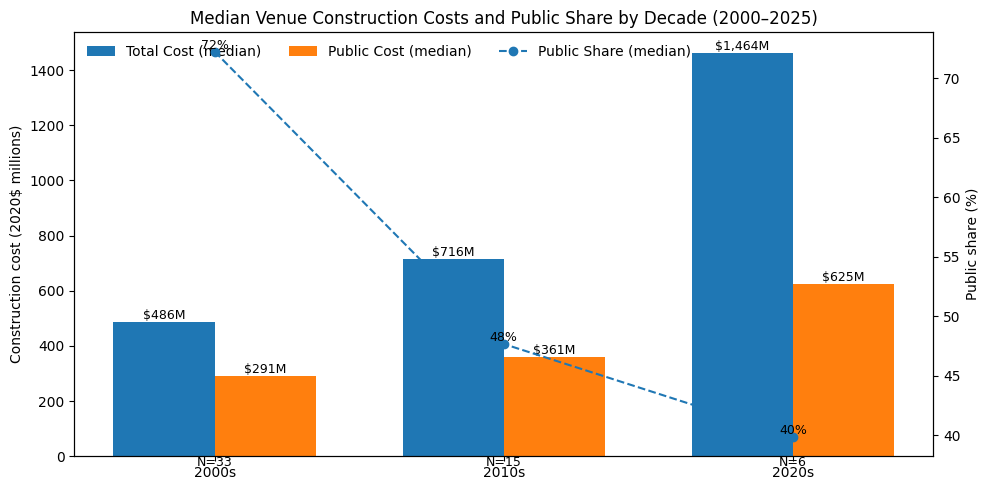

,med_total,med_public,med_share,N,med_share_pct
decade,,,,,
2000s,486.00000,290.54001,0.722567,33,72.3
2010s,716.41998,360.87999,0.476867,15,47.7
2020s,1464.00000,625.00000,0.398689,6,39.9


In [2]:
# Paths
EVENTS_CSV = r"/Users/mickeynguyen/Documents/School /Stadium Paper/Output/events_2000_2025_allleagues.csv"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Load & clean ---
ev = pd.read_csv(EVENTS_CSV)

# Keep years in window
ev["open_year"] = pd.to_numeric(ev["open_year"], errors="coerce")
ev = ev[(ev["open_year"] >= 2000) & (ev["open_year"] <= 2025)].copy()

# Ensure numeric costs (millions, 2020$)
for c in ["totalcost2020","publiccost2020","pubpct100"]:
    if c in ev.columns:
        ev[c] = pd.to_numeric(ev[c], errors="coerce")

# Treat zeros as missing for medians
ev.loc[ev["totalcost2020"]<=0, "totalcost2020"] = np.nan
ev.loc[ev["publiccost2020"]<=0, "publiccost2020"] = np.nan

# Compute public share if not trustworthy/absent (clip to [0,1])
ev["public_share"] = ev["publiccost2020"] / ev["totalcost2020"]
ev.loc[~np.isfinite(ev["public_share"]), "public_share"] = np.nan
ev["public_share"] = ev["public_share"].clip(lower=0, upper=1)

# --- 2) Build decade buckets ---
def decade_bucket(y):
    if 2000 <= y <= 2009:  return "2000s"
    if 2010 <= y <= 2019:  return "2010s"
    if 2020 <= y <= 2025:  return "2020s"
    return np.nan

ev["decade"] = ev["open_year"].map(decade_bucket)

# --- 3) Aggregate medians by decade ---
order = ["2000s","2010s","2020s"]
g = (ev.groupby("decade", as_index=True)
       .agg(med_total=("totalcost2020", "median"),
            med_public=("publiccost2020", "median"),
            med_share=("public_share", "median"),
            N=("venuename","size"))
       .reindex(order))

# Drop rows with no events
g = g[g["N"].fillna(0) > 0]

# --- 4) Plot: bars (medians of costs) + line (median public share) ---
x = np.arange(len(g))
w = 0.35

fig, ax = plt.subplots(figsize=(10,5))
b1 = ax.bar(x - w/2, g["med_total"].values, width=w, label="Total Cost (median)")
b2 = ax.bar(x + w/2, g["med_public"].values, width=w, label="Public Cost (median)")

ax.set_xticks(x)
ax.set_xticklabels(g.index)
ax.set_ylabel("Construction cost (2020$ millions)")
ax.set_title("Median Venue Construction Costs and Public Share by Decade (2000–2025)")

ax2 = ax.twinx()
line = ax2.plot(x, (g["med_share"]*100).values, marker="o", linestyle="--",
                label="Public Share (median)")
ax2.set_ylabel("Public share (%)")

# Combine legends
h1,l1 = ax.get_legend_handles_labels()
h2,l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc="upper left", ncol=3, frameon=False)

# --- 5) Annotations ---
def fmt_money(m):
    return f"${m:,.0f}M" if pd.notna(m) else ""

def annotate_bars(bars):
    for r in bars:
        v = r.get_height()
        if pd.notna(v):
            ax.text(r.get_x()+r.get_width()/2, v, fmt_money(v),
                    ha="center", va="bottom", fontsize=9)

annotate_bars(b1)
annotate_bars(b2)

for xi, p in enumerate((g["med_share"]*100).values):
    if pd.notna(p):
        ax2.text(xi, p, f"{p:.0f}%", ha="center", va="bottom", fontsize=9)

# Optional: show N per decade under tick labels
for xi, n in enumerate(g["N"].values):
    ax.text(xi, ax.get_ylim()[0], f"N={int(n)}", ha="center", va="top", fontsize=9)

plt.tight_layout()
plt.show()

# Quick sanity table
g.assign(med_share_pct=(g["med_share"]*100).round(1))

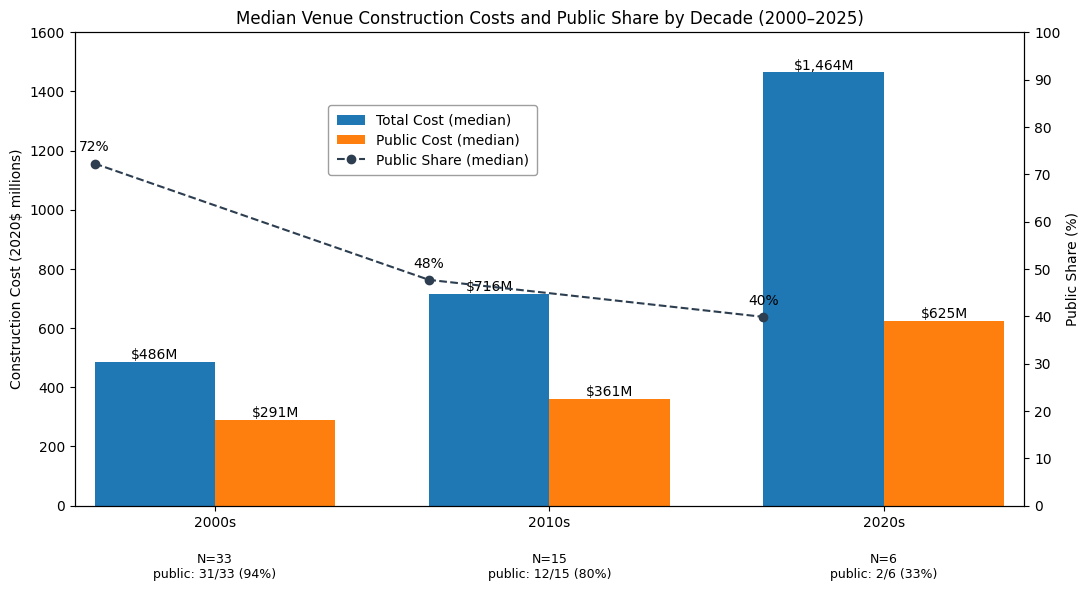

In [3]:
# Paths
EVENTS_CSV = r"/Users/mickeynguyen/Documents/School /Stadium Paper/Output/events_2000_2025_allleagues.csv"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------- Load & prep ----------
ev = pd.read_csv(EVENTS_CSV)
ev["open_year"] = pd.to_numeric(ev["open_year"], errors="coerce")
for c in ["totalcost2020", "publiccost2020", "pubpct100"]:
    ev[c] = pd.to_numeric(ev[c], errors="coerce")

ev = ev[(ev["open_year"] >= 2000) & (ev["open_year"] <= 2025)].copy()
ev.loc[ev["totalcost2020"] <= 0, "totalcost2020"] = np.nan

# keep private builds for TOTAL medians; exclude them for PUBLIC medians/share
ev["public_pos"] = ev["publiccost2020"] > 0
ev.loc[~ev["public_pos"], "publiccost2020"] = np.nan
ev["public_share"] = (ev["publiccost2020"] / ev["totalcost2020"]).clip(0, 1)

def decade_bucket(y):
    return ("2000s" if 2000 <= y <= 2009 else
            "2010s" if 2010 <= y <= 2019 else
            "2020s" if 2020 <= y <= 2025 else np.nan)

ev["decade"] = ev["open_year"].map(decade_bucket)

order = ["2000s", "2010s", "2020s"]
g = (ev.groupby("decade", as_index=True)
       .agg(med_total=("totalcost2020", "median"),
            med_public=("publiccost2020", "median"),
            med_share=("public_share", "median"),
            N_total=("venuename", "size"),
            N_public=("public_pos", "sum"))
       .reindex(order))
g = g[g["N_total"].fillna(0) > 0]

# ---------- Plot ----------
x = np.arange(len(g))
w = 0.36

TOTAL_COLOR  = "#1f77b4"
PUBLIC_COLOR = "#ff7f0e"
LINE_COLOR   = "#2c3e50"

fig, ax = plt.subplots(figsize=(11, 6))
ax2 = ax.twinx()

# Bars
b1 = ax.bar(x - w/2, g["med_total"].values,  width=w, color=TOTAL_COLOR,  label="Total Cost (median)")
b2 = ax.bar(x + w/2, g["med_public"].values, width=w, color=PUBLIC_COLOR, label="Public Cost (median)")

# Public share line – dot at LEFT EDGE of total bar
x_share = np.array([rect.get_x() for rect in b1])  # left edges of blue bars
ax2.plot(x_share, (g["med_share"] * 100).values, marker="o", linestyle="--",
         color=LINE_COLOR, label="Public Share (median)", zorder=5)

# ===== Tighten horizontal whitespace around bars =====
left_edge  = min([r.get_x() for r in list(b1) + list(b2)])
right_edge = max([r.get_x() + r.get_width() for r in list(b1) + list(b2)])
ax.set_xlim(left_edge - 0.06, right_edge + 0.06)   # small pad on each side
ax.margins(x=0)                                    # no extra automatic padding

# Axes + labels
ax.set_ylim(0, 1600)
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
ax.set_xticks(x)
ax.set_xticklabels(g.index)
ax.set_ylabel("Construction Cost (2020$ millions)")
ax2.set_ylabel("Public Share (%)")
ax.set_title("Median Venue Construction Costs and Public Share by Decade (2000–2025)")
from matplotlib.ticker import FuncFormatter

# Legend INSIDE
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc="upper left", bbox_to_anchor=(0.26, 0.86),
          frameon=True, framealpha=0.95, edgecolor="#999999", ncol=1,
          borderpad=0.6, labelspacing=0.4)

# Bar labels
def label_money(bars):
    for r in bars:
        v = r.get_height()
        if np.isfinite(v):
            ax.text(r.get_x() + r.get_width()/2, v, f"${v:,.0f}M",
                    ha="center", va="bottom", fontsize=10)
label_money(b1); label_money(b2)

# Percent labels at dots
for xi, p in zip(x_share, (g["med_share"]*100).values):
    if np.isfinite(p):
        ax2.text(xi, p + 2, f"{p:.0f}%", ha="center", va="bottom", fontsize=10)

# N labels beneath ticks
for xi, (n_tot, n_pub) in enumerate(zip(g["N_total"].values, g["N_public"].values)):
    pct = (n_pub / n_tot * 100) if n_tot else 0
    ax.text(xi, -0.10, f"N={int(n_tot)}\npublic: {int(n_pub)}/{int(n_tot)} ({pct:.0f}%)",
            transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=9, clip_on=False)

plt.tight_layout()
plt.show()

/var/folders/jz/f_xwhp0d6b9bslqfq_83rz6m0000gn/T/ipykernel_5146/3822181335.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showfliers=True)


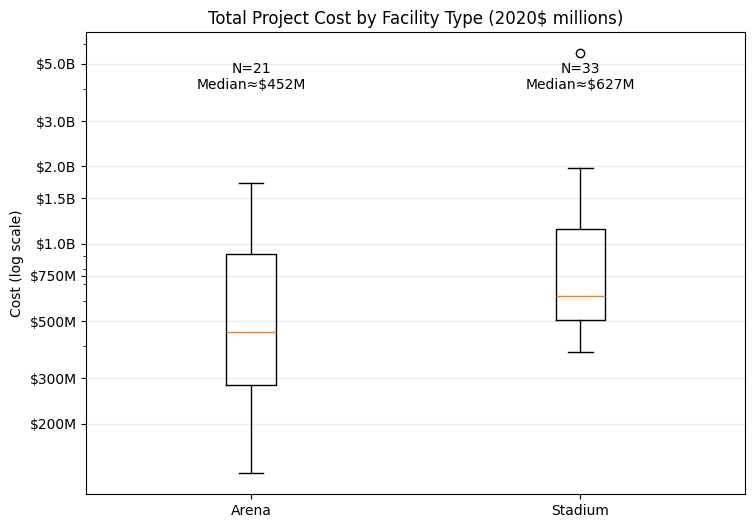

In [4]:
# Boxplots: total project cost (2020$ millions) — Arena vs Stadium (log y-axis)

EVENTS_CSV = r"/Users/mickeynguyen/Documents/School /Stadium Paper/Output/events_2000_2025_allleagues.csv"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load & prep
ev = pd.read_csv(EVENTS_CSV)
ev["facility_type"]  = ev["facility_type"].astype(str).str.lower()
ev["totalcost2020"]  = pd.to_numeric(ev["totalcost2020"], errors="coerce")

# Keep valid costs (in millions, >0)
df = ev.loc[ev["totalcost2020"].gt(0), ["facility_type","totalcost2020"]].copy()

arena = df.loc[df["facility_type"]=="arena",   "totalcost2020"].values
stadm = df.loc[df["facility_type"]=="stadium", "totalcost2020"].values

labels = ["Arena", "Stadium"]
data   = [arena, stadm]

# Helper for nice $M / $B tick labels
def fmt_million_ticks(vals):
    out = []
    for v in vals:
        if v >= 1000:
            out.append(f"${v/1000:.1f}B")
        else:
            out.append(f"${v:.0f}M")
    return out

# Build the figure
fig, ax = plt.subplots(figsize=(8.5, 6))

# Boxplot (defaults; no custom colors)
bp = ax.boxplot(data, labels=labels, showfliers=True)

# Log y-axis for readability
ax.set_yscale("log")

# Choose sensible dollar ticks inside data range
all_vals = np.concatenate([arena, stadm]) if (len(arena)+len(stadm)) else np.array([100,1000])
ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
candidates = np.array([50, 100, 200, 300, 500, 750, 1000, 1500, 2000, 3000, 5000])  # in millions
ticks = candidates[(candidates >= max(0.8*ymin, 1)) & (candidates <= 1.2*ymax)]
if ticks.size == 0:  # fallback
    ticks = candidates
ax.set_yticks(ticks)
ax.set_yticklabels(fmt_million_ticks(ticks))

ax.set_title("Total Project Cost by Facility Type (2020$ millions)")
ax.set_ylabel("Cost (log scale)")

# Light grid on y only
ax.grid(axis="y", alpha=0.25)

# Annotate N and medians above each box
y_top = ax.get_ylim()[1]
for i, arr in enumerate(data, start=1):
    if len(arr) == 0:
        continue
    med = np.median(arr)
    ax.text(i, y_top/1.3, f"N={len(arr)}\nMedian≈{fmt_million_ticks([med])[0]}",
            ha="center", va="top")

plt.subplots_adjust(top=0.88)
plt.show()

/var/folders/jz/f_xwhp0d6b9bslqfq_83rz6m0000gn/T/ipykernel_5146/1669800358.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)


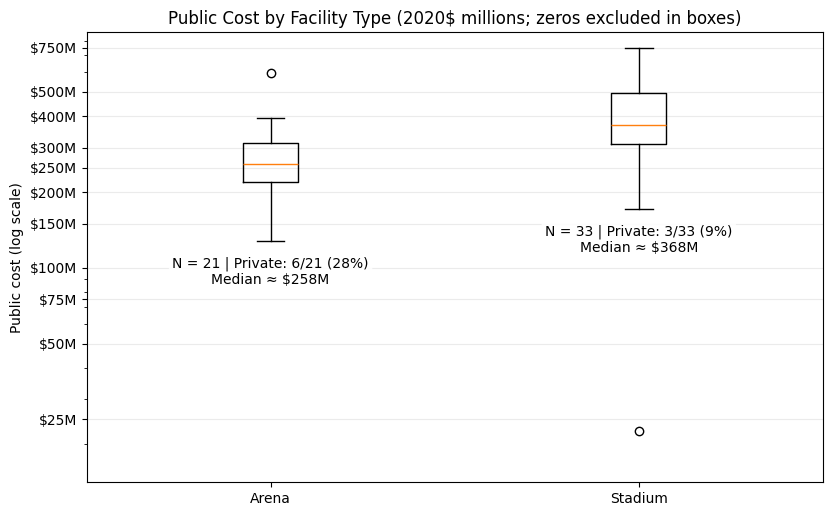

In [5]:
# One figure: Public cost (2020$M) — Arena vs Stadium
# Annotations placed below the LOWER WHISKER (exclude bottom outliers)

EVENTS_CSV = r"/Users/mickeynguyen/Documents/School /Stadium Paper/Output/events_2000_2025_allleagues.csv"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load & prep
ev = pd.read_csv(EVENTS_CSV)
ev["facility_type"]   = ev["facility_type"].astype(str).str.lower()
ev["publiccost2020"]  = pd.to_numeric(ev["publiccost2020"], errors="coerce")

# Summary counts (original N + private share)
summary = (
    ev.groupby("facility_type")
      .agg(total=("publiccost2020","size"),
           n_private=("publiccost2020", lambda s: (pd.to_numeric(s, errors="coerce").fillna(0) <= 0).sum()))
      .reindex(["arena","stadium"])
)
summary["share_private"] = (summary["n_private"] / summary["total"]).round(3)

# Data for boxes: only public$>0
arena_pub = ev.loc[(ev["facility_type"]=="arena")   & (ev["publiccost2020"]>0), "publiccost2020"].to_numpy()
stadm_pub = ev.loc[(ev["facility_type"]=="stadium") & (ev["publiccost2020"]>0), "publiccost2020"].to_numpy()

labels = ["Arena", "Stadium"]
data   = [arena_pub, stadm_pub]

def fmt_money(vals):
    return [f"${v/1000:.1f}B" if v >= 1000 else f"${v:.0f}M" for v in vals]

# Helper: lower whisker (min among non-outliers)
def lower_whisker(arr):
    if len(arr) == 0:
        return np.nan
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    lower_cut = q1 - 1.5 * iqr
    cand = arr[arr >= lower_cut]
    return np.min(cand) if cand.size else np.min(arr)

lw_ar = lower_whisker(arena_pub)
lw_st = lower_whisker(stadm_pub)

# y ticks & limits
all_pub = np.concatenate([arena_pub, stadm_pub]) if (len(arena_pub)+len(stadm_pub)) else np.array([50,100])
ymin_d = max(1, np.nanmin(all_pub))
ymax_d = np.nanmax(all_pub)
cands  = np.array([25, 50, 75, 100, 150, 200, 250, 300, 400, 500, 750, 1000, 1500, 2000, 3000, 5000])
ticks  = cands[(cands >= 0.6*ymin_d) & (cands <= 1.3*ymax_d)]
if ticks.size == 0: ticks = cands

y_lo = ymin_d / 1.6   # footroom for below-whisker labels
y_hi = ymax_d * 1.15

fig, ax = plt.subplots(figsize=(9.5, 6))
ax.boxplot(data, labels=labels, showfliers=True)
ax.set_title("Public Cost by Facility Type (2020$ millions; zeros excluded in boxes)")
ax.set_ylabel("Public cost (log scale)")
ax.set_yscale("log")
ax.set_ylim(y_lo, y_hi)
ax.set_yticks(ticks); ax.set_yticklabels(fmt_money(ticks))
ax.grid(axis="y", alpha=0.25)

# Place label just below the lower whisker (divide by ~1.15 to go slightly below)
def label_below_whisker(x_pos, kind, arr, whisker_min):
    s = summary.loc[kind]
    text = (
        f"N = {int(s['total'])} | Private: {int(s['n_private'])}/{int(s['total'])} "
        f"({int(100*s['share_private'])}%)\n"
        f"Median ≈ {fmt_money([np.median(arr)])[0] if len(arr) else '—'}"
    )
    if np.isfinite(whisker_min):
        y_pos = max(y_lo*1.02, whisker_min / 1.15)
    else:
        y_pos = y_lo * 1.05
    ax.text(x_pos, y_pos, text, ha="center", va="top",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.9))

label_below_whisker(1, "arena",   arena_pub, lw_ar)
label_below_whisker(2, "stadium", stadm_pub, lw_st)

plt.subplots_adjust(top=0.86)
plt.show()

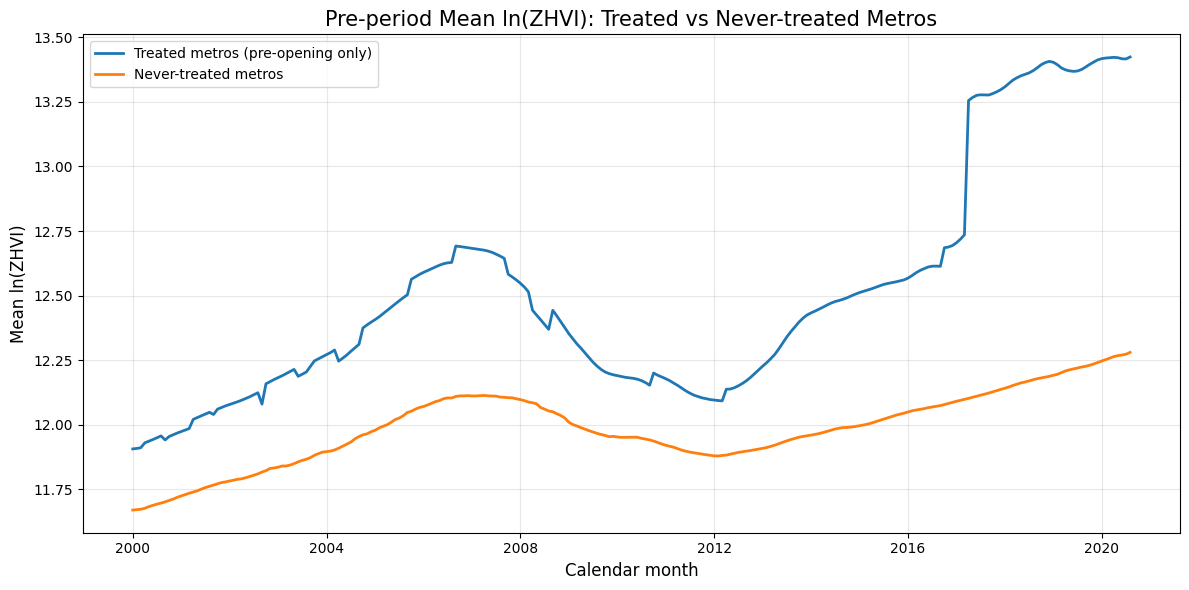

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load data ---
CSV = r"/Users/mickeynguyen/Documents/School /Stadium Paper/Output/zhvi_metro_month_with_openings.csv"
df = pd.read_csv(CSV)

# --- 2. Basic cleaning + log transform ---
df["ym"] = pd.to_datetime(df["ym"])
df["open_ym"] = pd.to_datetime(df["open_ym"])
df = df[df["zhvi"] > 0].copy()
df["ln_zhvi"] = np.log(df["zhvi"])

# --- 3. Identify treated vs never-treated metros ---
df["is_treated"] = df["open_ym"].notna()

# First opening per treated metro
first_open = (
    df[df["is_treated"]]
    .groupby("metro_name")["open_ym"]
    .min()
)

df["first_open_ym"] = df["metro_name"].map(first_open)

# Treated observations: pre-period only (before first opening in that metro)
treated_pre = df[
    df["is_treated"] &
    (df["ym"] < df["first_open_ym"])
].copy()

# Controls: metros that never have an opening in 2000–2025
control = df[~df["is_treated"]].copy()

# To make the comparison fair, restrict control to the same calendar window
min_pre_date = treated_pre["ym"].min()
max_pre_date = treated_pre["ym"].max()
control_pre = control[
    (control["ym"] >= min_pre_date) &
    (control["ym"] <= max_pre_date)
].copy()

# --- 4. Compute monthly mean ln(ZHVI) by group ---
treated_series = (
    treated_pre
    .groupby("ym")["ln_zhvi"]
    .mean()
    .rename("treated_mean")
)

control_series = (
    control_pre
    .groupby("ym")["ln_zhvi"]
    .mean()
    .rename("control_mean")
)

plot_df = pd.concat([treated_series, control_series], axis=1)

# Optional: drop months where one group is missing
plot_df = plot_df.dropna(subset=["treated_mean", "control_mean"])

# --- 5. Plot ---
plt.figure(figsize=(12, 6))
plt.plot(
    plot_df.index,
    plot_df["treated_mean"],
    label="Treated metros (pre-opening only)",
    linewidth=2
)
plt.plot(
    plot_df.index,
    plot_df["control_mean"],
    label="Never-treated metros",
    linewidth=2
)

plt.title("Pre-period Mean ln(ZHVI): Treated vs Never-treated Metros", fontsize=15)
plt.xlabel("Calendar month", fontsize=12)
plt.ylabel("Mean ln(ZHVI)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

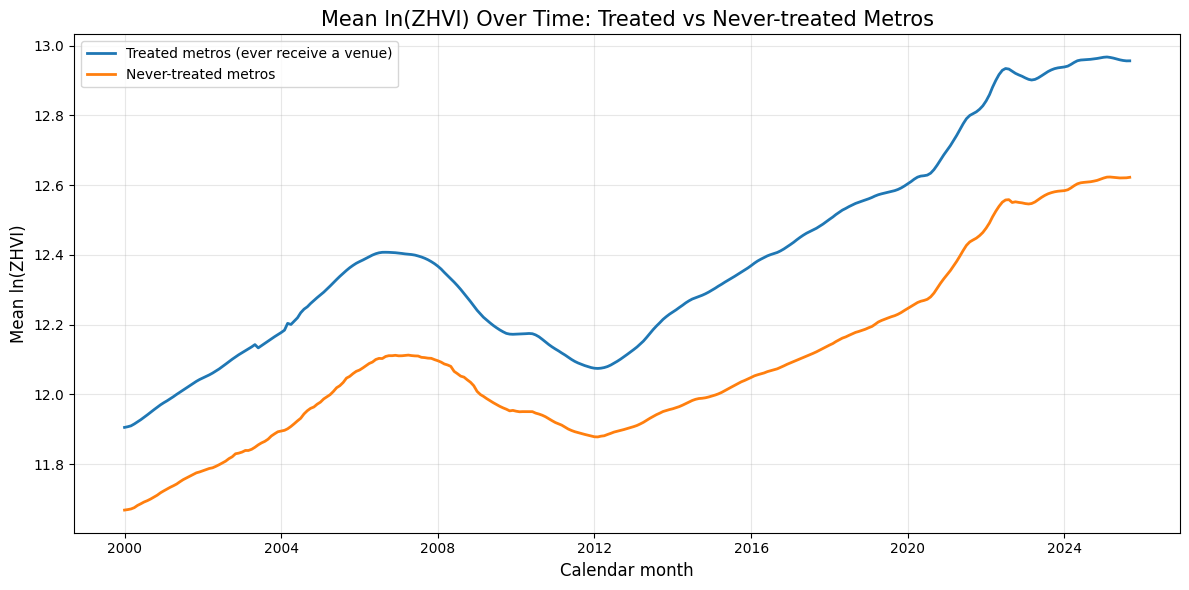

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load data ---
CSV = r"/Users/mickeynguyen/Documents/School /Stadium Paper/Output/zhvi_metro_month_with_openings.csv"
df = pd.read_csv(CSV)

# --- 2. Basic cleaning: dates + log(ZHVI) ---
df["ym"] = pd.to_datetime(df["ym"])
df = df[df["zhvi"] > 0].copy()
df["ln_zhvi"] = np.log(df["zhvi"])

# --- 3. Define treated vs never-treated metros ---
# treated = metros that ever have an opening in 2000–2025
df["is_treated_metro"] = df["open_ym"].notna()

treated = df[df["is_treated_metro"]].copy()
control = df[~df["is_treated_metro"]].copy()

# --- 4. Monthly mean ln(ZHVI) for each group ---
treated_mean = (
    treated.groupby("ym")["ln_zhvi"]
    .mean()
    .rename("treated_mean")
)

control_mean = (
    control.groupby("ym")["ln_zhvi"]
    .mean()
    .rename("control_mean")
)

plot_df = pd.concat([treated_mean, control_mean], axis=1)

# If there are months where one group is missing, drop them
plot_df = plot_df.dropna(subset=["treated_mean", "control_mean"])

# --- 5. Plot ---
plt.figure(figsize=(12, 6))

plt.plot(
    plot_df.index,
    plot_df["treated_mean"],
    label="Treated metros (ever receive a venue)",
    linewidth=2
)
plt.plot(
    plot_df.index,
    plot_df["control_mean"],
    label="Never-treated metros",
    linewidth=2
)

plt.title("Mean ln(ZHVI) Over Time: Treated vs Never-treated Metros", fontsize=15)
plt.xlabel("Calendar month", fontsize=12)
plt.ylabel("Mean ln(ZHVI)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()